# Bluesky Data Science
## Part 08 - LLMs as Research Assistants: Classification and Annotation at Scale

June 2026
Copyright and distributed under an [MIT License](https://opensource.org/licenses/MIT)

## Background

> **tl;dr**: Large language models can label social media posts at a scale no human coding team can match — but an LLM is a measurement instrument, and instruments have to be validated. This notebook builds a small content-analysis pipeline: collect posts, write a codebook, hand-code a gold-standard sample, run an automated annotator, and quantify how much to trust it.

### The hand-coding bottleneck

Classic content analysis asks humans to read documents and assign them to categories defined in a *codebook*: is this post about politics? Does it express a stance? Is it toxic? Human coding produces high-quality measures, but it is slow and expensive. A trained coder might label a few hundred short posts per hour; a research question that needs 100,000 labeled posts becomes a budget line, not an afternoon.

Large language models promise to break that bottleneck. [Gilardi, Alizadeh, and Kubli (2023)](https://www.pnas.org/doi/10.1073/pnas.2305016120) found that ChatGPT out-performed Mechanical Turk crowd workers on several tweet-annotation tasks (relevance, stance, topics, frames) at roughly one-thirtieth the cost, and [Törnberg (2023)](https://arxiv.org/abs/2304.06588) found GPT-4 classified the partisanship of Twitter users more accurately than both experts and crowd workers. But the same literature urges caution: [Ziems et al. (2024)](https://doi.org/10.1162/coli_a_00502) benchmarked LLMs across two dozen computational social science tasks and concluded they can *augment* — not yet *replace* — human annotation, with performance that varies sharply by task and prompt.

The discipline that reconciles the promise with the caution is **validation**: compare the automated labels to a human-coded gold standard, report agreement statistics, and read the disagreements. That is exactly what we will do here.

### What we will build

1. A corpus of ~150 recent original posts from one account, collected through `get_author_feed` (Part 01 skills).
2. A three-category topic codebook tailored to that account.
3. A gold-standard sample of 60 posts hand-coded with that codebook (shipped with this notebook).
4. Fully written LLM-annotation code using Anthropic's Claude API — guarded so the notebook runs with or without an API key.
5. A transparent keyword-rule **baseline annotator** that always runs, so the validation mechanics execute for real.
6. Validation: accuracy, percent agreement, Cohen's kappa, a confusion matrix, per-category precision and recall, and an error analysis of the disagreements.

### Learning objectives

By the end of this notebook you will be able to:

1. Explain why automated annotation (LLM or otherwise) must be validated against human-coded gold labels before its output is used as a research measure.
2. Write a codebook with category definitions, decision rules, and edge-case guidance that both humans and an LLM can apply.
3. Construct an annotation prompt that requests strict JSON output, and parse the responses defensively.
4. Estimate the token cost of an LLM annotation job before running it, and batch requests politely.
5. Compute and interpret accuracy, percent agreement, Cohen's kappa, confusion matrices, and per-category precision/recall with scikit-learn.
6. Conduct an error analysis of human–machine disagreements and explain why chance-corrected agreement matters when categories are imbalanced (the prevalence problem).
7. Articulate when LLM labels are — and are not — defensible as research measures, and document an annotation pipeline for reproducibility.

## Setup

We need the usual libraries plus two helper modules that live next to this notebook:

* `bsky_client.py` — the shared authentication helper used throughout this series. It returns an authenticated client if you have saved credentials in `atproto.json` (see Part 00) and otherwise falls back to the unauthenticated public AppView, which serves every endpoint we need here.
* `annotate.py` — the part-specific helper module containing the codebook, the LLM annotation functions, and the keyword baseline.

The imports below also pull four functions from [scikit-learn's model-evaluation toolkit](https://scikit-learn.org/stable/modules/model_evaluation.html) — `accuracy_score`, `cohen_kappa_score`, `confusion_matrix`, and `classification_report`. These are the workhorses of the validation in Section 6; we will define each one as we use it.

In [1]:
# Standard library
import os
import json
import time
from datetime import datetime, timezone

# DataFrames
import pandas as pd
import numpy as np

# Data visualization
%matplotlib inline
import matplotlib.pyplot as plt

# Agreement metrics
from sklearn.metrics import (
    accuracy_score,
    cohen_kappa_score,
    confusion_matrix,
    classification_report,
)

With the libraries loaded, we create the API client. `get_client()` looks for saved credentials and, finding none, falls back to Bluesky's **public AppView** (`https://public.api.bsky.app`) — the unauthenticated, read-only server that serves public data such as profiles and author feeds (see the [HTTP API reference at docs.bsky.app](https://docs.bsky.app/docs/category/http-reference)). Everything in this notebook works either way: you do not need a Bluesky account, an app password, or an API key of any kind to run it end-to-end.

In [2]:
from bsky_client import get_client, is_authenticated

client = get_client()

No atproto.json found: using the unauthenticated public AppView.
Read endpoints work; search and write endpoints require logging in.


## 1. Collecting a corpus of posts

Every annotation project starts with a corpus. We will reuse the pagination skills from Part 01 to collect roughly **150 recent original posts** from the author's account, `brianckeegan.com`, using the [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed) endpoint — the same one Part 01 introduced; its parameters and response shape are documented at [docs.bsky.app](https://docs.bsky.app). Two filters keep the corpus clean:

* `filter='posts_no_replies'` asks the API to exclude replies, so we get top-level posts.
* The feed can still contain **reposts** of other people's content. A repost shows up with a `reason` attached to the feed item, so we skip any item where `item.reason` is not `None`. Reposts are someone *else's* words — labeling them as this account's content would contaminate the measure.

We also keep engagement counts, which are handy for sanity checks, and we sleep briefly between pages to be polite to the API.

In [3]:
TARGET_POSTS = 150
ACTOR = 'brianckeegan.com'

posts = []
cursor = None

while len(posts) < TARGET_POSTS:
    feed_page = client.get_author_feed(
        actor = ACTOR,
        limit = 100,
        cursor = cursor,
        filter = 'posts_no_replies'
    )

    for item in feed_page.feed:
        # Skip reposts: they carry a "reason" explaining why they're in the feed
        if item.reason is not None:
            continue
        record = item.post.record
        # Belt-and-suspenders: skip anything that is somehow a reply
        if getattr(record, 'reply', None) is not None:
            continue
        posts.append({
            'uri': item.post.uri,
            'created_at': record.created_at,
            'text': record.text,
            'like_count': item.post.like_count,
            'repost_count': item.post.repost_count,
            'reply_count': item.post.reply_count,
        })

    cursor = feed_page.cursor
    if cursor is None:   # ran out of history
        break
    time.sleep(0.1)      # be polite between paginated calls

posts = posts[:TARGET_POSTS]
print(f"Collected {len(posts)} original posts from {ACTOR}")

Collected 150 original posts from brianckeegan.com


Flatten the list of dictionaries into a tidy DataFrame. Some posts have **no text at all** — they are image-only posts. Our codebook (next section) applies to text, so we set those aside and keep the posts with text.

In [4]:
posts_df = pd.DataFrame(posts)

n_empty = (posts_df['text'].str.strip() == '').sum()
posts_df = posts_df[posts_df['text'].str.strip() != ''].reset_index(drop=True)

print(f"Dropped {n_empty} image-only posts with empty text; {len(posts_df)} posts remain")
posts_df.head()

Dropped 12 image-only posts with empty text; 138 posts remain


,uri,created_at,text,like_count,repost_count,reply_count
0,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,2026-06-09T20:46:51.855Z,"It's the same ""as an avid bicyclist, I am oppo...",18,3,0
1,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,2026-06-09T20:37:13.813Z,I am so excited to finally get access to @anth...,8,0,1
2,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,2026-06-09T14:36:43.938Z,If politicians are unwilling to commit to coun...,6,2,0
3,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,2026-06-09T14:33:57.358Z,But what about her emails,2,1,0
4,at://did:plc:lse7quaysss2d3xxm76mouhd/app.bsky...,2026-06-05T11:39:28.862Z,The dolts at POLITICO and on Wall Street:,3,1,0


Following the reproducibility conventions of this series, we save the corpus along with the collection date and parameters. The numbers in this section will drift between runs — the account keeps posting — which is exactly why the gold-standard sample in the next sections ships as a *fixed file* rather than being rebuilt live.

In [5]:
collection_metadata = {
    'actor': ACTOR,
    'endpoint': 'app.bsky.feed.getAuthorFeed',
    'filter': 'posts_no_replies',
    'reposts_excluded': True,
    'target_posts': TARGET_POSTS,
    'n_collected': len(posts_df),
    'collected_at': datetime.now(timezone.utc).isoformat(),
}

posts_df.to_csv('data/posts.csv', index=False)
with open('data/collection_metadata.json', 'w') as f:
    json.dump(collection_metadata, f, indent=2)

collection_metadata

{'actor': 'brianckeegan.com',
 'endpoint': 'app.bsky.feed.getAuthorFeed',
 'filter': 'posts_no_replies',
 'reposts_excluded': True,
 'target_posts': 150,
 'n_collected': 138,
 'collected_at': '2026-06-10T11:00:03.917860+00:00'}

## 2. Constructing a codebook

Before any labeling — human or machine — we need a **codebook**: the document that defines the categories, the rules for choosing between them, and guidance for the hard cases. In a real project the codebook is developed iteratively: draft categories, have two or more coders apply them to a pilot sample, measure **inter-coder reliability** — a chance-corrected statistic (such as Cohen's kappa or Krippendorff's alpha) that quantifies how often independent coders assign the same label to the same item — discuss the disagreements, revise, and repeat until the categories are reliable ([Krippendorff 2018](https://us.sagepub.com/en-us/nam/content-analysis/book258450) is the standard methods text). The codebook *is* the measurement instrument; an LLM prompt is just a delivery mechanism for it.

We read through the collected posts before writing this codebook — always look at your data first. This account posts a lot of US political commentary, a substantial amount about academia, research, and AI, and a long tail of jokes, music, and everyday life. That suggests a three-category topic scheme:

| Label | Definition |
|---|---|
| `politics` | Government, elections, parties, politicians, courts, legislation, public policy (including local/housing policy), war and geopolitics, and criticism of political news media. |
| `science_tech` | Science, research, academia, higher education, teaching, grants, scholarly publishing, data science, AI/LLMs, software, and the technology industry — where the practice or culture of science/technology is the main subject. |
| `other` | Everything else: personal life, jokes without a clearly political or technical referent, pop culture, food, sports, and posts whose topic cannot be determined from text alone. |

**Decision rules** resolve the predictable conflicts. The most important one here is rule 2: when a post criticizes *political actors acting on* science or universities (defunding agencies, censoring campuses), we code `politics` — the political action is the subject, the academy is merely the object. **Edge-case guidance** records the judgment calls made while piloting the codebook, so future coders (and the LLM) make the same calls.

The full codebook lives in `annotate.py` as the `CODEBOOK` string constant, so the exact text we hand to human coders is the exact text we will embed in the LLM prompt — one instrument, two operators.

In [6]:
from annotate import (
    CODEBOOK,
    LABELS,
    build_prompt,
    parse_label_response,
    annotate_posts_llm,
    estimate_annotation_cost,
    keyword_label,
    KEYWORD_RULES,
)

print(CODEBOOK)

TASK: Assign each Bluesky post exactly one topic label.

LABELS

politics — The post is primarily about government, elections, political
  parties, politicians, courts, legislation, public policy (national, state,
  or local — including housing and urban policy), war and geopolitics, or
  criticism of political news media and pundits.

science_tech — The post is primarily about science, research, academia,
  higher education, teaching, grants, scholarly publishing, data science,
  AI/LLMs, software, or the technology industry, where the practice or
  culture of science/technology (not a political actor) is the main subject.

other — Everything else: personal life, jokes and memes without a clearly
  political or scientific/technical referent, pop culture, music, food,
  sports, local community chatter, and posts whose topic cannot be
  determined from the text alone.

DECISION RULES

1. Code the post's PRIMARY topic — what the post is mostly about, not every
   topic it touches.
2. If 

## 3. Gold-standard labels

To validate any automated annotator we need a **gold standard**: a sample of posts labeled by humans applying the codebook. This notebook ships with `data/gold_labels.csv`, containing **60 posts hand-coded by the tutorial authors** using the codebook above, at the time this notebook was written.

> **An honesty note.** These are *example* labels coded by the tutorial authors so the validation workflow below runs end-to-end. In real research you would use two or more trained human coders working independently, measure and report **inter-coder reliability** (e.g., Krippendorff's alpha or Cohen's kappa *between the humans*) before treating their consensus as gold, and document how disagreements were adjudicated. A gold standard coded by one person is itself an unvalidated instrument — do as we say, not as we do.

The file also includes a `label_rationale` column for ten of the trickier posts, recording *why* the decision rules produced each label. Writing rationales during coding is cheap and pays for itself the first time you revisit a category boundary.

In [7]:
gold = pd.read_csv('data/gold_labels.csv')
gold['label_rationale'] = gold['label_rationale'].fillna('')

print(f"{len(gold)} gold-labeled posts")
gold[['created_at', 'text', 'gold_label']].head(8)

60 gold-labeled posts


,created_at,text,gold_label
0,2026-06-09T20:46:51.855Z,"It's the same ""as an avid bicyclist, I am oppo...",politics
1,2026-06-09T20:37:13.813Z,I am so excited to finally get access to @anth...,science_tech
2,2026-06-09T14:36:43.938Z,If politicians are unwilling to commit to coun...,politics
3,2026-06-09T14:33:57.358Z,But what about her emails,politics
4,2026-06-05T11:39:28.862Z,The dolts at POLITICO and on Wall Street:,politics
5,2026-06-02T20:59:34.093Z,If you thought meat and dairy was expensive be...,other
6,2026-06-01T00:08:18.884Z,A very big reason why we’re stuck with Boomer ...,politics
7,2026-05-31T11:27:15.081Z,“That's what I paid for: not to learn whether ...,science_tech


Because the corpus above is collected live, the account will have posted new things since the gold sample was coded — so the gold file carries its own `text` column and the validation below runs entirely from the saved file. Let's check how much the live corpus still overlaps with the gold sample, and look at the label distribution.

60 of 60 gold-labeled posts are still in today's live corpus
gold_label
politics        38
other           12
science_tech    10
Name: count, dtype: int64


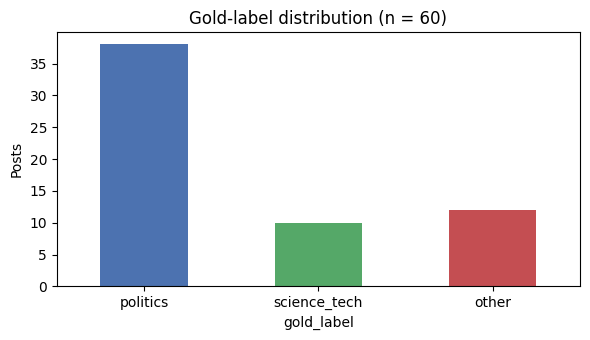

In [8]:
overlap = gold['uri'].isin(posts_df['uri']).sum()
print(f"{overlap} of {len(gold)} gold-labeled posts are still in today's live corpus")

label_counts = gold['gold_label'].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(6, 3.5))
label_counts.reindex(LABELS).plot(kind='bar', ax=ax, color=['#4c72b0', '#55a868', '#c44e52'])
ax.set_ylabel('Posts')
ax.set_title('Gold-label distribution (n = 60)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

Note the **imbalance**: politics dominates. That imbalance — the *prevalence* of the categories — will matter a lot when we interpret agreement statistics later.

Here are a few of the recorded rationales, which show the decision rules doing real work:

In [9]:
with pd.option_context('display.max_colwidth', None):
    display(gold.loc[gold['label_rationale'] != '',
                     ['text', 'gold_label', 'label_rationale']].head(4))

,text,gold_label,label_rationale
5,If you thought meat and dairy was expensive before…,other,"Likely reacting to a news item about food prices, but the referent is undecidable from the text alone (rule 6) -> other."
8,Seismometers measured something associated with #Boston #explosion at 2:16 ET: www.volcanodiscovery.com/earthquakes/...,other,"Reports a local explosion event; mentions seismometers but the primary topic is a news event, not research practice or politics -> other."
9,"We're not even dismantling our legacy scientific institutions to create something better, it is quite simply a project of retribution from some of the dumbest people in the world.",politics,"The affected domain is science, but the post targets political actors dismantling institutions (rule 2) -> politics."
13,Rewind the clock 50 years and assumptions that unvarying birth rates will produce absurd overpopulation justified very real and violent and coercive policies.\n\nThe underpopulation panic is the exact same project of racist anxiety using the same bad math.\n\nRead my book about it in 2028!,politics,"Mentions the author's forthcoming book, but the primary topic is population panic as a political-ideological project (rules 1 and 4) -> politics."


## 4. LLM annotation with the Claude API

Now the core of the LLM-as-annotator workflow. Conceptually it is four steps:

1. **Build a prompt** that embeds the codebook and one post, and demands machine-readable output.
2. **Call the model** once per post.
3. **Parse** the response defensively — models occasionally wrap JSON in markdown fences or add prose.
4. **Sleep between requests and catch errors per post**, so a long batch doesn't trip rate limits or lose everything to one failed request.

Everything API-specific below — the Messages endpoint, model names, rate limits, prompting guidance — is covered in [Anthropic's API documentation](https://docs.claude.com). You don't need a key to follow this section: the code is fully written and printed, and the one cell that would actually call the API is guarded so it explains itself instead when no key is present.

### 4.1 The prompt

`build_prompt` in `annotate.py` wraps the codebook and the post in XML-style tags (a convention Claude is trained to respect) and requests strict JSON: a `label` from our scheme and a `confidence` between 0 and 1. Asking for confidence costs almost nothing and gives you an uncertainty signal you can use later — e.g., routing low-confidence posts to human review.

Two terms of art are worth fixing here. Requesting machine-readable output in a fixed schema (our one-line JSON object) instead of free prose is called **structured output** — it is what makes ten thousand responses parseable by a loop rather than by a human. And our prompt is **zero-shot**: it gives the model instructions (the codebook) but *no worked examples* of labeled posts. A **few-shot** prompt adds a handful of labeled examples for the model to imitate; that often helps, and we return to the trade-offs in Section 8.

In [10]:
example_post = gold['text'].iloc[0]
print(build_prompt(CODEBOOK, example_post))

You are a careful content-analysis research assistant. Apply the codebook below to the post and respond with ONLY a JSON object — no preamble, no markdown fences.

<codebook>
TASK: Assign each Bluesky post exactly one topic label.

LABELS

politics — The post is primarily about government, elections, political
  parties, politicians, courts, legislation, public policy (national, state,
  or local — including housing and urban policy), war and geopolitics, or
  criticism of political news media and pundits.

science_tech — The post is primarily about science, research, academia,
  higher education, teaching, grants, scholarly publishing, data science,
  AI/LLMs, software, or the technology industry, where the practice or
  culture of science/technology (not a political actor) is the main subject.

other — Everything else: personal life, jokes and memes without a clearly
  political or scientific/technical referent, pop culture, music, food,
  sports, local community chatter, and posts w

### 4.2 The annotation loop

The function below (printed from `annotate.py`) is the complete batching loop. A few design points worth reading for:

* It uses `anthropic.Anthropic()`, which reads the API key from the `ANTHROPIC_API_KEY` environment variable — never hard-code keys in notebooks.
* `model="claude-sonnet-4-6"` with `max_tokens=256`: classification needs only a tiny output budget, and a mid-tier model is typically plenty for a well-specified codebook. **Record the exact model string with your results** — it is part of your instrument.
* `time.sleep()` between requests, and a per-post `try/except` so one rate-limit error doesn't discard a thousand completed labels.
* Every response goes through `parse_label_response`, which strips markdown fences, tolerates surrounding prose, and rejects labels outside the codebook — returning `label=None` rather than crashing.

In [11]:
import inspect
print(inspect.getsource(annotate_posts_llm))

def annotate_posts_llm(texts, codebook=CODEBOOK, model=DEFAULT_MODEL,
                       sleep_seconds=0.5, verbose=True):
    """Annotate an iterable of post texts with Claude, returning a list of dicts.

    Requires the ``anthropic`` package and an ``ANTHROPIC_API_KEY``
    environment variable. When either is missing this function explains what
    would happen and returns ``None`` instead of raising, so notebooks that
    call it always execute.

    The loop sleeps between requests to stay politely under rate limits and
    catches per-post API errors so one failure doesn't lose the whole batch.
    """
    import os
    if not os.environ.get("ANTHROPIC_API_KEY"):
        print(
            "No ANTHROPIC_API_KEY found in the environment, so no API calls "
            "were made.\nTo run LLM annotation: create a key at "
            "https://console.anthropic.com/, run\n"
            "`pip install anthropic`, export ANTHROPIC_API_KEY, and re-run "
            "this cell.\nEach

The parser deserves a quick test on the failure modes you will actually see in the wild:

In [12]:
test_responses = [
    '{"label": "politics", "confidence": 0.92}',                 # clean JSON
    '```json\n{"label": "other", "confidence": 0.5}\n```',       # fenced
    'Sure! {"label": "science_tech", "confidence": 0.7}',         # prose-wrapped
    'This post is about politics.',                               # no JSON at all
    '{"label": "sports", "confidence": 1.0}',                     # not in the codebook
]
for raw in test_responses:
    print(f"{raw[:48]:<50} -> {parse_label_response(raw)}")

{"label": "politics", "confidence": 0.92}          -> {'label': 'politics', 'confidence': 0.92, 'error': None}
```json
{"label": "other", "confidence": 0.5}
``   -> {'label': 'other', 'confidence': 0.5, 'error': None}
Sure! {"label": "science_tech", "confidence": 0.   -> {'label': 'science_tech', 'confidence': 0.7, 'error': None}
This post is about politics.                       -> {'label': None, 'confidence': None, 'error': 'invalid JSON'}
{"label": "sports", "confidence": 1.0}             -> {'label': None, 'confidence': None, 'error': "invalid label: 'sports'"}


All five test cases come back as either a clean label or an explicit `label=None` with an error message — nothing raises an exception. That is the property you want in a loop that will run thousands of times unattended: bad responses become *rows you can count and inspect*, not crashes that lose the batch.

### 4.3 What will this cost?

Always run the back-of-envelope *before* the batch. Each request pays for the codebook again — roughly 600 tokens of instructions per post (at scale, [prompt caching](https://platform.claude.com/docs/en/build-with-claude/prompt-caching) and the 50%-discounted Batches API exist for exactly this) — plus the post itself, plus a small JSON output.

At June 2026 prices, `claude-sonnet-4-6` costs \$3 per million input tokens and \$15 per million output tokens. `estimate_annotation_cost` uses the crude ~4-characters-per-token heuristic; the API's `count_tokens` endpoint gives exact numbers when you have a key.

In [13]:
for model in ['claude-haiku-4-5', 'claude-sonnet-4-6']:
    est = estimate_annotation_cost(gold['text'].tolist(), model=model)
    print(f"{model}: ~{est['est_input_tokens']:,} input tokens for {est['n_posts']} posts "
          f"-> ~${est['est_cost_usd']:.2f} total, ~${est['est_cost_per_1k_posts_usd']:.2f} per 1,000 posts")

claude-haiku-4-5: ~44,228 input tokens for 60 posts -> ~$0.05 total, ~$0.89 per 1,000 posts
claude-sonnet-4-6: ~44,228 input tokens for 60 posts -> ~$0.16 total, ~$2.66 per 1,000 posts


A few dollars per thousand posts means a 100,000-post corpus costs a few hundred dollars. Compare that to crowd-worker rates of roughly \$0.05–0.15 *per label* — \$5,000–15,000 per 100k posts before quality control — and you see why Gilardi et al. reported a ~30x cost advantage. The bottleneck genuinely moves from labeling to validating.

### 4.4 Running the annotator (guarded)

This tutorial environment has **no API key**, so the cell below will print an explanation instead of making API calls — and that is by design: the notebook must run end-to-end for every reader. If you set `ANTHROPIC_API_KEY` (and `pip install anthropic`), the very same cell annotates all 60 gold posts and saves the labels to `data/llm_labels.csv`. Nothing else in the notebook needs to change.

In [14]:
llm_results = None

if os.environ.get('ANTHROPIC_API_KEY'):
    try:
        import anthropic  # the SDK: pip install anthropic
        llm_results = annotate_posts_llm(gold['text'].tolist())
    except ImportError:
        print("The `anthropic` package is not installed. Run `pip install anthropic` first.")
else:
    print("No ANTHROPIC_API_KEY set, so no posts were sent to the API.")
    print("To run LLM annotation: get a key at https://console.anthropic.com/,")
    print("`pip install anthropic`, export ANTHROPIC_API_KEY, and re-run this cell.")
    print("It would send each gold post to claude-sonnet-4-6 with the codebook prompt,")
    print("sleep 0.5s between requests, parse the JSON labels, and cost about $0.16.")

if llm_results is not None:
    llm_df = pd.DataFrame(llm_results)
    llm_df.to_csv('data/llm_labels.csv', index=False)
    print(f"Saved {len(llm_df)} LLM labels to data/llm_labels.csv")

No ANTHROPIC_API_KEY set, so no posts were sent to the API.
To run LLM annotation: get a key at https://console.anthropic.com/,
`pip install anthropic`, export ANTHROPIC_API_KEY, and re-run this cell.
It would send each gold post to claude-sonnet-4-6 with the codebook prompt,
sleep 0.5s between requests, parse the JSON labels, and cost about $0.16.


## 5. A baseline annotator that always runs

We promised the validation mechanics would *execute for real* in this notebook, key or no key. So we need an automated annotator that works offline. `annotate.py` provides a deliberately simple **keyword-rule classifier**: two hand-curated keyword lists (one per substantive category), whole-word matching, most hits wins, and ties or zero-hit posts fall through to `other`.

> **Framing matters:** this is a *stand-in automated annotator* so we can practice validation — explicitly **not** a claim that keyword matching rivals an LLM. The point is that the validation workflow in Section 6 is identical no matter what produced the predicted column: a dictionary, a supervised classifier, or `claude-sonnet-4-6`. When you have a key, swap `baseline_label` for the LLM labels from Section 4 and re-run Sections 6–7 unchanged.

Keyword dictionaries are also a genuinely useful methodological foil: they are *fully transparent* (you can read the entire "model" in ten seconds) and *perfectly reproducible* (the same input always yields the same label) — two properties LLM annotators conspicuously lack. What they trade away is any understanding of context, which the error analysis will make painfully visible.

In [15]:
for category, keywords in KEYWORD_RULES.items():
    print(f"{category} ({len(keywords)} keywords):")
    print('  ' + ', '.join(keywords[:14]) + ', ...')

print('\nExamples:')
for text in ['Final grades submitted.',
             'Thank a Trump voter.',
             'Provolone is the worst cheese for a sandwich.']:
    print(f"  {keyword_label(text):>12} <- {text!r}")

politics (56 keywords):
  trump, biden, democrat, democrats, democratic, republican, republicans, gop, congress, congressional, senate, senators, scotus, court, ...
science_tech (49 keywords):
  ai, llm, llms, research, researchers, science, scientific, scientist, scientists, university, universities, professor, professoriate, academic, ...

Examples:
  science_tech <- 'Final grades submitted.'
      politics <- 'Thank a Trump voter.'
         other <- 'Provolone is the worst cheese for a sandwich.'


Now apply the baseline to all 60 gold posts and save the predictions next to the gold labels in `data/baseline_predictions.csv`. Saving predictions and gold labels side by side means anyone — including future you — can re-run the validation in Section 6 from the file alone, without re-running the annotator.

In [16]:
gold['baseline_label'] = gold['text'].apply(keyword_label)

gold[['uri', 'text', 'gold_label', 'baseline_label']].to_csv(
    'data/baseline_predictions.csv', index=False)

gold[['text', 'gold_label', 'baseline_label']].head(8)

,text,gold_label,baseline_label
0,"It's the same ""as an avid bicyclist, I am oppo...",politics,politics
1,I am so excited to finally get access to @anth...,science_tech,science_tech
2,If politicians are unwilling to commit to coun...,politics,politics
3,But what about her emails,politics,other
4,The dolts at POLITICO and on Wall Street:,politics,other
5,If you thought meat and dairy was expensive be...,other,other
6,A very big reason why we’re stuck with Boomer ...,politics,politics
7,“That's what I paid for: not to learn whether ...,science_tech,science_tech


As an aside: VADER (from Part 06) is *another* automated annotator we could validate exactly the same way — it labels sentiment rather than topic. One quick look at how sentiment varies across our gold topics, just to make the point that "automated annotator" is a family with many members:

In [17]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()
gold['vader_compound'] = gold['text'].apply(
    lambda t: analyzer.polarity_scores(t)['compound'])

gold.groupby('gold_label')['vader_compound'].agg(['mean', 'median', 'count']).round(3)

,mean,median,count
gold_label,,,
other,-0.053,0.000,12
politics,0.139,0.115,38
science_tech,0.150,0.127,10


(If we wanted to *use* those sentiment scores in research, we would need a sentiment gold standard and the same validation pass we are about to run for topics. "Validate, validate, validate" — Grimmer & Stewart 2013.)

## 6. Validation: how good is the automated annotator?

Now the heart of the notebook. We compare `baseline_label` against `gold_label` on all 60 posts.

### 6.1 Accuracy, percent agreement, and Cohen's kappa

* **Accuracy / percent agreement** — the share of posts where machine and human agree, computed with scikit-learn's [`accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html). (With one machine label and one gold label per post these are the same number; "percent agreement" is the term the content-analysis literature uses for any pair of coders.)
* **Cohen's kappa** ([`cohen_kappa_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.cohen_kappa_score.html)) corrects agreement for chance: $\kappa = \frac{p_o - p_e}{1 - p_e}$, where $p_o$ is observed agreement and $p_e$ is the agreement two coders would reach by guessing independently with their respective label frequencies. A coder that labels *everything* `politics` would agree with our gold standard most of the time while contributing zero information — kappa exposes that; accuracy alone does not.

In [18]:
y_true = gold['gold_label']
y_pred = gold['baseline_label']

accuracy = accuracy_score(y_true, y_pred)
percent_agreement = (y_true == y_pred).mean()
kappa = cohen_kappa_score(y_true, y_pred)

print(f"Accuracy:           {accuracy:.3f}")
print(f"Percent agreement:  {percent_agreement:.1%}")
print(f"Cohen's kappa:      {kappa:.3f}")

# What would a lazy "always predict the modal label" coder score?
modal_label = y_true.mode()[0]
lazy = pd.Series([modal_label] * len(y_true), index=y_true.index)
print(f"\nAlways-'{modal_label}' coder: accuracy {accuracy_score(y_true, lazy):.3f}, "
      f"kappa {cohen_kappa_score(y_true, lazy):.3f}")

Accuracy:           0.783
Percent agreement:  78.3%
Cohen's kappa:      0.640

Always-'politics' coder: accuracy 0.633, kappa 0.000


The lazy coder gets a deceptively respectable accuracy from prevalence alone — and a kappa of exactly 0. That is the **prevalence problem**: when one category dominates, raw agreement is inflated by chance, so always report a chance-corrected statistic alongside it. (Prevalence cuts the other way too: with extremely skewed categories, kappa can look harsh even when coders agree on nearly every post, because $p_e$ is enormous — another reason to publish the full confusion matrix rather than any single number.)

Our keyword annotator's kappa in the ~0.6 range lands in the band conventionally glossed as "substantial" agreement (Landis & Koch 1977), though conventions are no substitute for reading the errors. For calibration, Gilardi et al. (2023) found *trained human annotators* agreeing with each other at comparable or lower rates on harder tasks — agreement ceilings are properties of tasks, not just of coders.

### 6.2 Confusion matrix

A **confusion matrix** ([`confusion_matrix`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html)) is a square table with one row per *true* category and one column per *predicted* category. Counts on the diagonal are agreements; every off-diagonal cell is a specific, named kind of mistake. It shows *where* the disagreements live: rows are the human gold labels, columns are what the machine said.

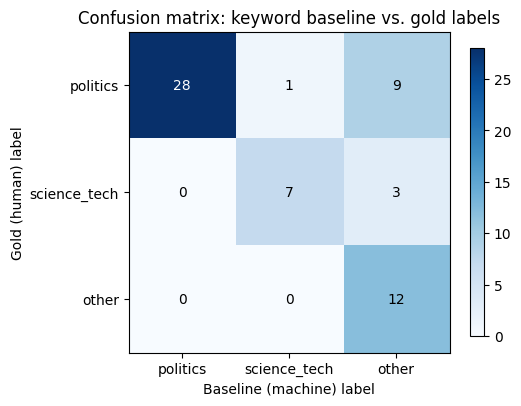

In [19]:
cm = confusion_matrix(y_true, y_pred, labels=LABELS)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(LABELS)), LABELS)
ax.set_yticks(range(len(LABELS)), LABELS)
ax.set_xlabel('Baseline (machine) label')
ax.set_ylabel('Gold (human) label')
ax.set_title('Confusion matrix: keyword baseline vs. gold labels')
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, cm[i, j], ha='center', va='center',
                color='white' if cm[i, j] > cm.max() / 2 else 'black')
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('data/confusion_matrix.png', dpi=150, bbox_inches='tight')

The dominant error mode sits in the `politics` row, `other` column: political posts the keyword lists failed to catch. That asymmetry is informative — the baseline almost never *invents* politics; it *misses* politics expressed without its keywords (sarcasm, allusion, in-jokes).

### 6.3 Per-category precision and recall

Aggregate numbers hide category-level failure. For each category: **precision** — when the machine says X, how often is it right? **Recall** — of the truly-X posts, how many did the machine find? If you plan to *study* one category (say, sample all the `science_tech` posts for close reading), its precision and recall matter far more than overall accuracy. Scikit-learn's [`classification_report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) computes both per category, along with their harmonic mean, the **F1 score**; the [user-guide chapter on precision, recall, and F-measures](https://scikit-learn.org/stable/modules/model_evaluation.html#precision-recall-f-measure-metrics) walks through the definitions carefully.

In [20]:
report = classification_report(y_true, y_pred, labels=LABELS,
                               output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T.round(3)
report_df

,precision,recall,f1-score,support
politics,1.000,0.737,0.848,38.000
science_tech,0.875,0.700,0.778,10.000
other,0.500,1.000,0.667,12.000
accuracy,0.783,0.783,0.783,0.783
macro avg,0.792,0.812,0.764,60.000
weighted avg,0.879,0.783,0.800,60.000


High precision but mediocre recall for `politics` and `science_tech`, and the mirror image for `other` (high recall, weak precision — because it absorbs every miss). A downstream analysis of "the politics posts" based on these labels would be clean but *incomplete* — and not randomly incomplete: it would systematically exclude the most allusive, context-dependent political speech. That is **measurement bias**, not just noise.

We save the metrics — together with the annotator's identity and the validation date — to `data/agreement_metrics.csv`. Versioning your validation results alongside your labels is part of the documentation burden of automated annotation.

In [21]:
metrics_rows = [
    {'metric': 'n_gold_posts', 'value': len(gold), 'category': ''},
    {'metric': 'accuracy', 'value': round(accuracy, 4), 'category': ''},
    {'metric': 'percent_agreement', 'value': round(percent_agreement, 4), 'category': ''},
    {'metric': 'cohen_kappa', 'value': round(kappa, 4), 'category': ''},
]
for cat in LABELS:
    for stat in ['precision', 'recall', 'f1-score']:
        metrics_rows.append({'metric': stat, 'value': round(report[cat][stat], 4),
                             'category': cat})

metrics_df = pd.DataFrame(metrics_rows)
metrics_df['annotator'] = 'keyword_baseline_v1'
metrics_df['validated_at'] = datetime.now(timezone.utc).date().isoformat()
metrics_df.to_csv('data/agreement_metrics.csv', index=False)
metrics_df

,metric,value,category,annotator,validated_at
0,n_gold_posts,60.0000,,keyword_baseline_v1,2026-06-10
1,accuracy,0.7833,,keyword_baseline_v1,2026-06-10
2,percent_agreement,0.7833,,keyword_baseline_v1,2026-06-10
3,cohen_kappa,0.6402,,keyword_baseline_v1,2026-06-10
4,precision,1.0000,politics,keyword_baseline_v1,2026-06-10
5,recall,0.7368,politics,keyword_baseline_v1,2026-06-10
6,f1-score,0.8485,politics,keyword_baseline_v1,2026-06-10
7,precision,0.8750,science_tech,keyword_baseline_v1,2026-06-10
8,recall,0.7000,science_tech,keyword_baseline_v1,2026-06-10
9,f1-score,0.7778,science_tech,keyword_baseline_v1,2026-06-10


## 7. Error analysis: read the disagreements

Statistics tell you *how much* the annotator fails; only reading the disagreements tells you *how* and *why*. Pull every post where machine and human disagree and read the first five closely.

In [22]:
disagreements = gold[gold['gold_label'] != gold['baseline_label']]
print(f"{len(disagreements)} disagreements out of {len(gold)} posts\n")

with pd.option_context('display.max_colwidth', 110):
    display(disagreements[['text', 'gold_label', 'baseline_label']].head(5))

13 disagreements out of 60 posts



,text,gold_label,baseline_label
3,But what about her emails,politics,other
4,The dolts at POLITICO and on Wall Street:,politics,other
9,"We're not even dismantling our legacy scientific institutions to create something better, it is quite simp...",politics,science_tech
13,Rewind the clock 50 years and assumptions that unvarying birth rates will produce absurd overpopulation ju...,politics,other
15,Over a decade of precedent unambiguously proves that “diversity of thought” is “my speech is entitled to ...,politics,other


Reading these five closely (numbered in row order above):

1. *"But what about her emails"* — gold `politics`, machine `other`. A five-word allusion to a decade-old political controversy. There is no keyword to catch; the meaning is entirely contextual. An LLM with world knowledge would almost certainly get this right — exactly the kind of error that separates dictionary methods from language models.
2. *"The dolts at POLITICO and on Wall Street:"* — gold `politics`, machine `other`. Criticism of political news media, but the codebook's *concept* ("political news media") is broader than any keyword list can enumerate. Dictionaries chase concepts; they never quite catch up.
3. *"We're not even dismantling our legacy scientific institutions…"* — gold `politics`, machine `science_tech`. The one disagreement where the machine *committed* rather than abstained — and it is precisely the decision-rule-2 case: science vocabulary in the text, but a political project as the subject. The keyword counter sees words; the rule requires understanding who is doing what to whom.
4. *"Rewind the clock 50 years…"* (overpopulation panic) — gold `politics`, machine `other`. The gold label leaned on the recorded edge-case guidance ("population/eugenics discourse framed as a political project → politics"). A genuinely hard case where reasonable human coders could disagree — which is exactly why the rationale was written down.
5. *"…'diversity of thought' is 'my speech is entitled to a mandatory audience'…"* — gold `politics`, machine `other`. Political-discourse criticism delivered in scare quotes, again keyword-free.

The pattern across the disagreements: **the baseline fails on context, allusion, and sarcasm — exactly where LLMs claim their advantage, and exactly where you should concentrate your validation effort when you test one.** Error analysis is not box-checking; it tells you what the *next* iteration of the codebook (or the prompt, or the annotator) needs to fix. It also occasionally flags gold-label mistakes — human coders err too, and validation cuts both ways.

## 8. When are LLM labels defensible as research measures?

Suppose you now add an API key, run Section 4, and find the LLM agrees with your gold labels at kappa = 0.85. What does defensible use of those labels look like? The emerging methodological consensus:

**Defensible practice**

* **Validate on a gold sample, every time.** Performance varies sharply across tasks, languages, and even prompt phrasings (Ziems et al. 2024). A kappa from someone else's paper — or from your own *previous* project — does not transfer.
* **Version everything**: the exact codebook text, the exact prompt template, the exact model string (`claude-sonnet-4-6`, not "Claude"), the parameters, and the dates. The prompt + model **is** your instrument; readers must be able to inspect it, and you must be able to detect when it changes underneath you.
* **Report uncertainty.** Publish the confusion matrix and per-category precision/recall, not a single accuracy number. If you collected confidence scores, use them — route low-confidence posts to human review, or propagate label uncertainty into downstream estimates rather than pretending the labels are exact.
* **Re-validate when anything changes** — a new time period, a new community, a new model version. Domain drift quietly degrades annotators that validated beautifully last year.

**Standing concerns**

* **Closed-model reproducibility.** Hosted models are updated and eventually retired; the same prompt can return different labels next year, and no parameter setting ever guaranteed identical outputs. Mitigations: save every raw model response (not just the parsed labels), pin dated model versions where the provider offers them, and report collection dates — while recognizing that, unlike a keyword dictionary, a hosted instrument can never be perfectly frozen. Open-weight models trade some capability for genuine freezability.
* **Zero-shot vs. few-shot.** Our prompt is *zero-shot*: codebook, post, no worked examples. Adding a handful of labeled examples to the prompt (*few-shot*) often helps — Gilardi et al. found zero-shot ChatGPT already competitive with crowd workers, while Ziems et al. document task-dependent gains from examples. Few-shot examples are part of the instrument too: choose them deliberately (cover the edge cases, not just the easy wins), document them, and never let your validation posts leak into the prompt.
* **The benchmark perspective.** Ziems et al.'s multi-task benchmark is a useful prior: LLMs do best on tasks with crisp, surface-visible definitions (topic, relevance) and worst on subtle latent constructs (implicit stance, figurative language, expert framing tasks). Calibrate your expectations — and your validation-sample size — to where your task sits on that spectrum.
* **Bias auditing.** LLM errors are not random: models can be systematically better at labeling some dialects, communities, or viewpoints than others. If your research design compares groups, validate *within* each group, not just overall.

## Ethics and limitations

**Sending user content to third-party servers.** Every post you annotate with a hosted LLM is transmitted to another company's infrastructure — in our case Anthropic's. The posts here are public, but public availability is not blanket consent (Fiesler & Proferes 2018), and users who tolerated their posts being *read* may not expect them to be *processed by an AI company*. Before annotating at scale: check the provider's data-use and retention terms (whether API inputs are used for training, and how long they are retained); minimize what you send — our prompt contains only the post text, not handles, DIDs, or profile data; consider your IRB's view on transmitting user data to a third party; and prefer locally run open-weight models for sensitive populations or topics where the transmission itself is the harm.

**One account, by consent.** We deliberately annotated the author's own account. Topic-labeling an arbitrary stranger's posting history produces a behavioral profile of a person who never opted into being profiled. Legitimate designs exist (public officials, aggregates across many accounts), but they need justification — especially for categories more sensitive than "politics vs. other."

**The gold standard is the weakest link here.** Sixty posts coded by one author is a demonstration, not a measurement. Real projects need multiple independent coders, reported inter-coder reliability, and a validation sample sized to put acceptably tight confidence intervals on kappa — 60 posts leaves wide ones.

**Labels are not ground truth.** Even a perfect annotator only reproduces the codebook's worldview. Our rule 2, for instance, *constructs* a particular boundary between politics and academia rather than discovering one. Automated content analysis scales your codebook's assumptions right along with its categories.

**Representativeness.** One prolific, politically engaged academic's feed says nothing about Bluesky at large, and Bluesky's early-adopter, Twitter-migrant skew says nothing about the general public (Mislove et al. 2011). The pipeline transfers; the prevalence estimates do not.

## Exercises

1. **Extend the codebook to four categories.** Split `other` into `personal_humor` (jokes, memes, everyday life) and a fourth substantive category you observe in `data/posts.csv` (sports? music?). Update `LABELS`, the `CODEBOOK` text, and the decision rules in `annotate.py`, then re-read 20 posts and check that *you* can apply the new scheme consistently before asking any machine to. Notice how every added category creates new boundary disputes that need decision rules.

2. **Grow the gold standard and recompute.** Sample 20 posts from `data/posts.csv` that are *not* already in `data/gold_labels.csv`, hand-code them with the codebook, append them to the file (leave the original 60 rows untouched), and re-run Sections 5–6. Does kappa move? With n = 80 instead of 60, your estimates also get more stable — small validation samples leave wide uncertainty around kappa.

3. **Be a second coder.** Have a classmate independently code 20 of the gold posts using *only* the codebook text (no peeking at `gold_label`), then compute the human–human Cohen's kappa. Compare it to the machine–human kappa: agreement ceilings are properties of tasks, and the human–human number tells you what ceiling to expect.

4. **Improve the keyword baseline — carefully.** Read all of the disagreements from Section 7, add or remove keywords in `KEYWORD_RULES`, and re-run the validation. Then reflect: every fix you made used the gold sample itself, so your improved kappa is optimistic — you have effectively trained on your test set. How would you measure the improvement honestly?

5. **Run the real LLM annotator and compare.** Get an API key from [Anthropic](https://docs.claude.com), `pip install anthropic`, export `ANTHROPIC_API_KEY`, and re-run Section 4.4 (cost: well under a dollar). Then re-run Sections 6–7 with `llm_df['label']` in place of `baseline_label`. Where does the LLM beat the keywords — does it recover the allusive political posts from the error analysis? Where does it still disagree with the gold labels?

6. **Test prompt variations.** With a key, try at least two variants: (a) delete the EDGE-CASE GUIDANCE block from the codebook before building prompts, and (b) add three labeled few-shot examples to the prompt (chosen from posts *outside* the gold sample — never let validation posts leak into the prompt). Recompute kappa for each variant. How sensitive is your "instrument" to its wording?

## Research project ideas

**1. Does one validation generalize across communities?** LLM annotators are usually validated once, on one sample — but Bluesky hosts very different communities. *Question:* does an annotator (LLM or otherwise) validated on one community's posts perform equally well on another's? *Data:* posts from accounts in two contrasting starter packs or feeds (Part 09 shows how to enumerate them) — say, academic Bluesky versus sports or fandom Bluesky. *Method:* one shared codebook; a separate human-coded gold sample of 60–100 posts per community; per-community kappa, confusion matrices, and error analyses; a comparison of *where* the annotator fails in each. *Expected challenge:* building genuinely comparable gold standards — the codebook will fit one community better than the other, and you must disentangle annotator failure from codebook misfit, which is itself a finding worth reporting.

**2. Prompt and model sensitivity as a measurement-stability study.** If the prompt-plus-model is the instrument, how stable is the instrument? *Question:* how much do labels change across reasonable paraphrases of the same codebook, across zero-shot versus few-shot prompts, and across model tiers (e.g., `claude-haiku-4-5` versus `claude-sonnet-4-6`)? *Data:* a fixed corpus of ~500 posts plus a 100-post gold sample. *Method:* a factorial grid of prompt variants × models; for each cell, kappa against gold *and* pairwise label-flip rates between cells; identify which posts flip under every perturbation. *Expected challenge:* cost grows with the grid, and you must separate instrument instability from genuine ambiguity — posts that flip across prompts are often posts human coders would also dispute, so collect human disagreement data on the flippers.

**3. Validated prevalence estimation for political talk on Bluesky.** Much published Twitter work estimated the *prevalence* of some content category (incivility, misinformation engagement, political talk). *Question:* what share of posting by a defined population on Bluesky — e.g., accounts in a journalism starter pack — is political, and how did it change around a major news event (Part 05's event-study skills)? *Data:* author feeds for 50–100 accounts over several months. *Method:* LLM annotation at scale, validated against a stratified gold sample; crucially, correct the headline prevalence estimate for classifier error rather than just counting predicted labels, in the spirit of [Hopkins & King (2010)](https://doi.org/10.1111/j.1540-5907.2009.00428.x), since even a high-kappa annotator with asymmetric errors (like our baseline's politics-recall problem) biases raw category proportions. *Expected challenge:* misclassification correction needs good estimates of the error rates themselves, which pushes you toward a larger gold sample — budget your human-coding time as seriously as your API spend.

## References

### Scholarship

* Cohen, J. (1960). A coefficient of agreement for nominal scales. *Educational and Psychological Measurement*, 20(1), 37–46. [doi:10.1177/001316446002000104](https://doi.org/10.1177/001316446002000104)
* Fiesler, C., & Proferes, N. (2018). "Participant" perceptions of Twitter research ethics. *Social Media + Society*, 4(1). [doi:10.1177/2056305118763366](https://doi.org/10.1177/2056305118763366)
* Gilardi, F., Alizadeh, M., & Kubli, M. (2023). ChatGPT outperforms crowd workers for text-annotation tasks. *Proceedings of the National Academy of Sciences*, 120(30), e2305016120. [doi:10.1073/pnas.2305016120](https://doi.org/10.1073/pnas.2305016120)
* Grimmer, J., & Stewart, B. M. (2013). Text as data: The promise and pitfalls of automatic content analysis methods for political texts. *Political Analysis*, 21(3), 267–297. [doi:10.1093/pan/mps028](https://doi.org/10.1093/pan/mps028)
* Hopkins, D. J., & King, G. (2010). A method of automated nonparametric content analysis for social science. *American Journal of Political Science*, 54(1), 229–247. [doi:10.1111/j.1540-5907.2009.00428.x](https://doi.org/10.1111/j.1540-5907.2009.00428.x)
* Hutto, C., & Gilbert, E. (2014). VADER: A parsimonious rule-based model for sentiment analysis of social media text. *Proceedings of ICWSM*, 8(1), 216–225. [doi:10.1609/icwsm.v8i1.14550](https://doi.org/10.1609/icwsm.v8i1.14550)
* Krippendorff, K. (2018). [*Content Analysis: An Introduction to Its Methodology*](https://us.sagepub.com/en-us/nam/content-analysis/book258450) (4th ed.). SAGE Publications.
* Landis, J. R., & Koch, G. G. (1977). The measurement of observer agreement for categorical data. *Biometrics*, 33(1), 159–174. [doi:10.2307/2529310](https://doi.org/10.2307/2529310)
* Mislove, A., Lehmann, S., Ahn, Y.-Y., Onnela, J.-P., & Rosenquist, J. N. (2011). Understanding the demographics of Twitter users. *Proceedings of ICWSM*, 5(1), 554–557. [doi:10.1609/icwsm.v5i1.14168](https://doi.org/10.1609/icwsm.v5i1.14168)
* Törnberg, P. (2023). ChatGPT-4 outperforms experts and crowd workers in annotating political Twitter messages with zero-shot learning. *arXiv preprint*. [arXiv:2304.06588](https://arxiv.org/abs/2304.06588)
* Ziems, C., Held, W., Shaikh, O., Chen, J., Zhang, Z., & Yang, D. (2024). Can large language models transform computational social science? *Computational Linguistics*, 50(1), 237–291. [doi:10.1162/coli_a_00502](https://doi.org/10.1162/coli_a_00502)

### Documentation

* Bluesky HTTP API reference, including [`app.bsky.feed.getAuthorFeed`](https://docs.bsky.app/docs/api/app-bsky-feed-get-author-feed): [docs.bsky.app](https://docs.bsky.app)
* Anthropic Claude API documentation (Messages API, structured output, prompt caching, the Batches API): [docs.claude.com](https://docs.claude.com)
* scikit-learn model evaluation user guide (accuracy, kappa, confusion matrices, precision/recall/F1): [scikit-learn.org/stable/modules/model_evaluation.html](https://scikit-learn.org/stable/modules/model_evaluation.html)
* atproto Python SDK: [atproto.blue](https://atproto.blue)